In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df=pd.read_csv('monthly_milk_production.csv')
df.head(3)

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
### Converting the dtype of datetime 
df['Date']=pd.to_datetime(df['Date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        168 non-null    datetime64[ns]
 1   Production  168 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.8 KB


In [6]:
#Changing date time as index
df.set_index("Date", inplace=True)

In [7]:
### Checking for missing values
df.isnull().sum()

Production    0
dtype: int64

In [8]:
## Checking for duplicates
df.duplicated().sum()

np.int64(26)

In [9]:
## Dropping the duplicates permanently
df.drop_duplicates(inplace=True)

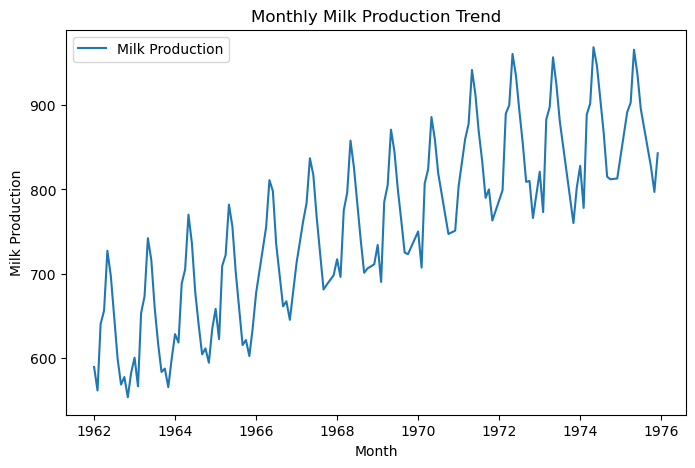

In [10]:
# Exploratory Data Analysis (EDA)
# Visualize trends, seasonality, and anomalies in the milk production data.
plt.figure(figsize=(8,5))
plt.plot(df, label="Milk Production")
plt.title("Monthly Milk Production Trend")
plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

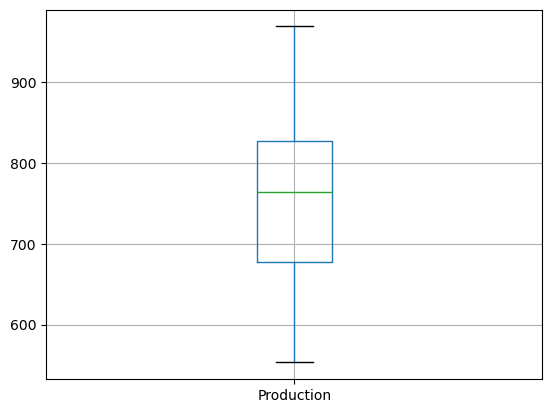

In [11]:
# Checking for outliers
df.boxplot()
plt.show()

In [12]:
### No outliers are present

In [13]:
### Applying nirmalization to the data set so as to bring the values in a particular range
min_max=MinMaxScaler()

In [14]:
scaled_data = min_max.fit_transform(df)

#### 2. Data Preparation for Deep Learning
Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
Split data into training, validation, and test sets.
Reshape data for model input dimensions.

In [15]:
# Creating input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12
X, y = create_sequences(scaled_data, WINDOW_SIZE)

In [16]:
# Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [17]:
# reshape data for input
X_train = X_train.reshape(X_train.shape[0], WINDOW_SIZE, 1)
X_test = X_test.reshape(X_test.shape[0], WINDOW_SIZE, 1)

#### 3. Model Building

In [19]:
# Model 1: Basic RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation="relu", input_shape=(WINDOW_SIZE, 1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer="adam", loss="mse")

print("\nTraining RNN Model...")
rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Training RNN Model...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1887
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1066
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0517
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0241
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0214
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0174
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0164
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0148
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0132
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0118
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0105
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0090
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0080
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0070
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0069
Epoch 16/50

In [20]:
# Similarly creating  Model 2: LSTM

lstm_model = Sequential()
lstm_model.add(LSTM(64, activation="relu", input_shape=(WINDOW_SIZE, 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

print("\nTraining LSTM Model...")
lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Training LSTM Model...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2976
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1709
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0763
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0250
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0319 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0222
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0239
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0218
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0214
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0213
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0207
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0204
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0199
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0196
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0191
Epoch 16/

In [21]:
# Now finally creating Model 3: GRU
gru_model = Sequential()
gru_model.add(GRU(64, activation="relu", input_shape=(WINDOW_SIZE, 1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer="adam", loss="mse")

print("\nTraining GRU Model...")
gru_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Training GRU Model...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.2888
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2033
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1386
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0878
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0501
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0320
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0322
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0283
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0274
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0268
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0259
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0262 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0250
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0249
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0240
Epoch 16/5

#### 4. Model Evaluation

In [25]:
#Calculating forecasting metrics: RMSE, MAE, MAPE.
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    predictions = min_max.inverse_transform(predictions)
    actual = min_max.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)

    return rmse, mae, predictions, actual
rnn_rmse, rnn_mae, rnn_pred, actual = evaluate_model(rnn_model, X_test, y_test)
lstm_rmse, lstm_mae, lstm_pred, _ = evaluate_model(lstm_model, X_test, y_test)
gru_rmse, gru_mae, gru_pred, _ = evaluate_model(gru_model, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


In [26]:
#Comparing the performances of RNN, LSTM, and GRU.

print("\n MODEL PERFORMANCE")
print("RNN RMSE:", rnn_rmse, " MAE:", rnn_mae)
print("LSTM RMSE:", lstm_rmse, " MAE:", lstm_mae)
print("GRU RMSE:", gru_rmse, " MAE:", gru_mae)


 MODEL PERFORMANCE
RNN RMSE: 29.592562931939735  MAE: 23.219738300030045
LSTM RMSE: 34.112096288648786  MAE: 28.668241060697103
GRU RMSE: 41.79387161128065  MAE: 33.13217397836537


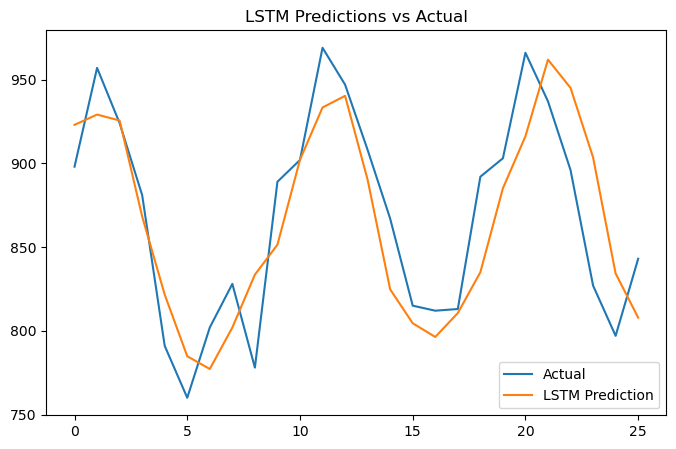

In [27]:
#Now plotting predictions vs. actual values.
plt.figure(figsize=(8,5))
plt.plot(actual, label="Actual")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.title("LSTM Predictions vs Actual")
plt.legend()
plt.show()

#### 5. Prediction and Visualization

In [30]:
# Forecast Next 12 Months
future_input = scaled_data[-WINDOW_SIZE:]
future_predictions = []

for i in range(12):
    pred = lstm_model.predict(future_input.reshape(1, WINDOW_SIZE, 1))
    future_predictions.append(pred[0])
    future_input = np.append(future_input[1:], pred)

future_predictions = min_max.inverse_transform(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [29]:
### Creating datasets for future data
future_dates = pd.date_range(start=df.index[-1], periods=12, freq="M")

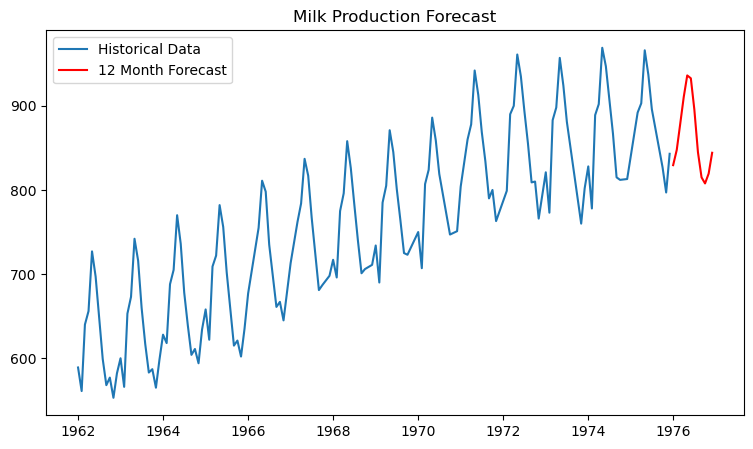

In [31]:
#  Plotting Forecast
plt.figure(figsize=(9,5))
plt.plot(df, label="Historical Data")
plt.plot(future_dates, future_predictions, label="12 Month Forecast", color="red")
plt.title("Milk Production Forecast")
plt.legend()
plt.show()

In [32]:
# Print Forecast Results
forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted Milk Production": future_predictions.flatten()
})

print("\n===== 12 MONTH FORECAST =====")
print(forecast_df)


===== 12 MONTH FORECAST =====
        Month  Predicted Milk Production
0  1975-12-31                 829.490046
1  1976-01-31                 847.622250
2  1976-02-29                 877.785147
3  1976-03-31                 910.494471
4  1976-04-30                 936.123083
5  1976-05-31                 932.728426
6  1976-06-30                 895.739592
7  1976-07-31                 844.956011
8  1976-08-31                 814.951384
9  1976-09-30                 807.759241
10 1976-10-31                 819.441383
11 1976-11-30                 844.208475


#### 6. Business Insights
Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

#### The forecasting results show a clear seasonal pattern and steady growth in milk production. The LSTM model provides the most accurate predictions among RNN, LSTM, and GRU.
#### Using these forecasts, the dairy business can:
. Plan storage and distribution during peak production months.

. Schedule workforce and operations efficiently.

. Avoid overproduction or shortages.

. Make better budgeting and expansion decisions based on expected future demand.

#### Overall, the forecasting model helps the company improve planning, reduce waste, and allocate resources more effectively.